<a href="https://colab.research.google.com/github/supreme-00/Agentic-Chatbot-Minor-Project/blob/main/Trading_Anomaly_Detection_Model_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

file_path = '/content/drive/MyDrive/DATA/synthetic_stock_data.csv'
data = pd.read_csv(file_path)

data.head(5)


,Date,Symbol,Close,Volume,Pct_Change
0,2023-01-01,AMZN,242.52,445209,3.56
1,2023-01-02,TSLA,462.73,554880,1.59
2,2023-01-03,MSFT,208.85,798079,-3.37
3,2023-01-04,TSLA,359.08,665076,-4.29
4,2023-01-05,TSLA,100.21,220963,1.42


In [ ]:
data = data[['Date', 'Symbol', 'Close', 'Volume']]
data.isnull().sum()

,0
Date,0
Symbol,0
Close,0
Volume,0


In [ ]:
data = data.dropna()
data = data.drop_duplicates()
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    150 non-null    object 
 1   Symbol  150 non-null    object 
 2   Close   150 non-null    float64
 3   Volume  150 non-null    int64  
dtypes: float64(1), int64(1), object(2)
memory usage: 4.8+ KB


In [ ]:
data['Price_Change'] = data.groupby('Symbol')['Close'].diff()
data['Movement'] = data['Price_Change'].apply(lambda x: 'Increase' if x > 0 else 'Decrease')

data_filtered = data[data['Movement'] == 'Increase']

transactions = data_filtered.groupby('Date')['Symbol'].apply(list).tolist()

transactions[:5]

/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


[['MSFT'], ['MSFT'], ['TSLA'], ['AMZN'], ['GOOGL']]

In [ ]:
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules
from mlxtend.preprocessing import TransactionEncoder
import pandas as pd

transactions = [['AAPL', 'MSFT'], ['GOOGL', 'AAPL', 'MSFT'], ['GOOGL', 'TSLA']]

te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df = pd.DataFrame(te_ary, columns=te.columns_)

frequent_itemsets = apriori(df, min_support=0.003, use_colnames=True)

print("Frequent Itemsets:")
frequent_itemsets


Frequent Itemsets:


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


,support,itemsets
0,0.666667,(AAPL)
1,0.666667,(GOOGL)
2,0.666667,(MSFT)
3,0.333333,(TSLA)
4,0.333333,"(AAPL, GOOGL)"
5,0.666667,"(AAPL, MSFT)"
6,0.333333,"(MSFT, GOOGL)"
7,0.333333,"(TSLA, GOOGL)"
8,0.333333,"(AAPL, MSFT, GOOGL)"


In [ ]:
from mlxtend.frequent_patterns import apriori
from mlxtend.preprocessing import TransactionEncoder
import pandas as pd

# Sample transactions (replace this with your actual transaction data)
transactions = [['AAPL', 'MSFT'], ['GOOGL', 'AAPL', 'MSFT'], ['GOOGL', 'TSLA']]

# Step 1: One-hot encode the transactions
te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df = pd.DataFrame(te_ary, columns=te.columns_)

# Step 2: Apply the apriori algorithm
frequent_itemsets = apriori(df, min_support=0.2, use_colnames=True)

# Step 3: Manually calculate confidence and lift
min_confidence = 0.5
min_lift = 1.0

rules_list = []
for index, row in frequent_itemsets.iterrows():
    itemset = row['itemsets']
    if len(itemset) > 1:  # Only consider itemsets with 2 or more items
        for item in itemset:
            # Calculate antecedent (X) and consequent (Y)
            antecedent = frozenset([item])
            consequent = itemset - antecedent

            # Calculate metrics
            support = row['support']
            antecedent_support = frequent_itemsets[frequent_itemsets['itemsets'] == antecedent]['support'].values[0]
            consequent_support = frequent_itemsets[frequent_itemsets['itemsets'] == consequent]['support'].values[0]

            confidence = support / antecedent_support
            lift = confidence / consequent_support

            # Filter rules based on thresholds
            if confidence >= min_confidence and lift >= min_lift:
                rules_list.append({
                    'antecedent': set(antecedent),
                    'consequent': set(consequent),
                    'support': support,
                    'confidence': confidence,
                    'lift': lift
                })

# Step 4: Display the rules
rules_df = pd.DataFrame(rules_list)
print(rules_df)


  antecedent     consequent   support  confidence  lift
0     {AAPL}         {MSFT}  0.666667         1.0   1.5
1     {MSFT}         {AAPL}  0.666667         1.0   1.5
2     {TSLA}        {GOOGL}  0.333333         1.0   1.5
3    {GOOGL}         {TSLA}  0.333333         0.5   1.5
4     {AAPL}  {MSFT, GOOGL}  0.333333         0.5   1.5
5     {MSFT}  {AAPL, GOOGL}  0.333333         0.5   1.5


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


In [ ]:
# Select and display top rules based on lift
rules_df = rules_df.sort_values(by='lift', ascending=False)
print(rules_df[['antecedent', 'consequent', 'support', 'confidence', 'lift']])


  antecedent     consequent   support  confidence  lift
0     {AAPL}         {MSFT}  0.666667         1.0   1.5
1     {MSFT}         {AAPL}  0.666667         1.0   1.5
2     {TSLA}        {GOOGL}  0.333333         1.0   1.5
3    {GOOGL}         {TSLA}  0.333333         0.5   1.5
4     {AAPL}  {MSFT, GOOGL}  0.333333         0.5   1.5
5     {MSFT}  {AAPL, GOOGL}  0.333333         0.5   1.5


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)
<ipython-input-52-93287d91eb57>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rules_df.index, y="support", data=rules_df, ax=axes[0], palette="viridis")
<ipython-input-52-93287d91eb57>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rules_df.index, y="confidence", data=rules_df, ax=axes[1], palette="magma")


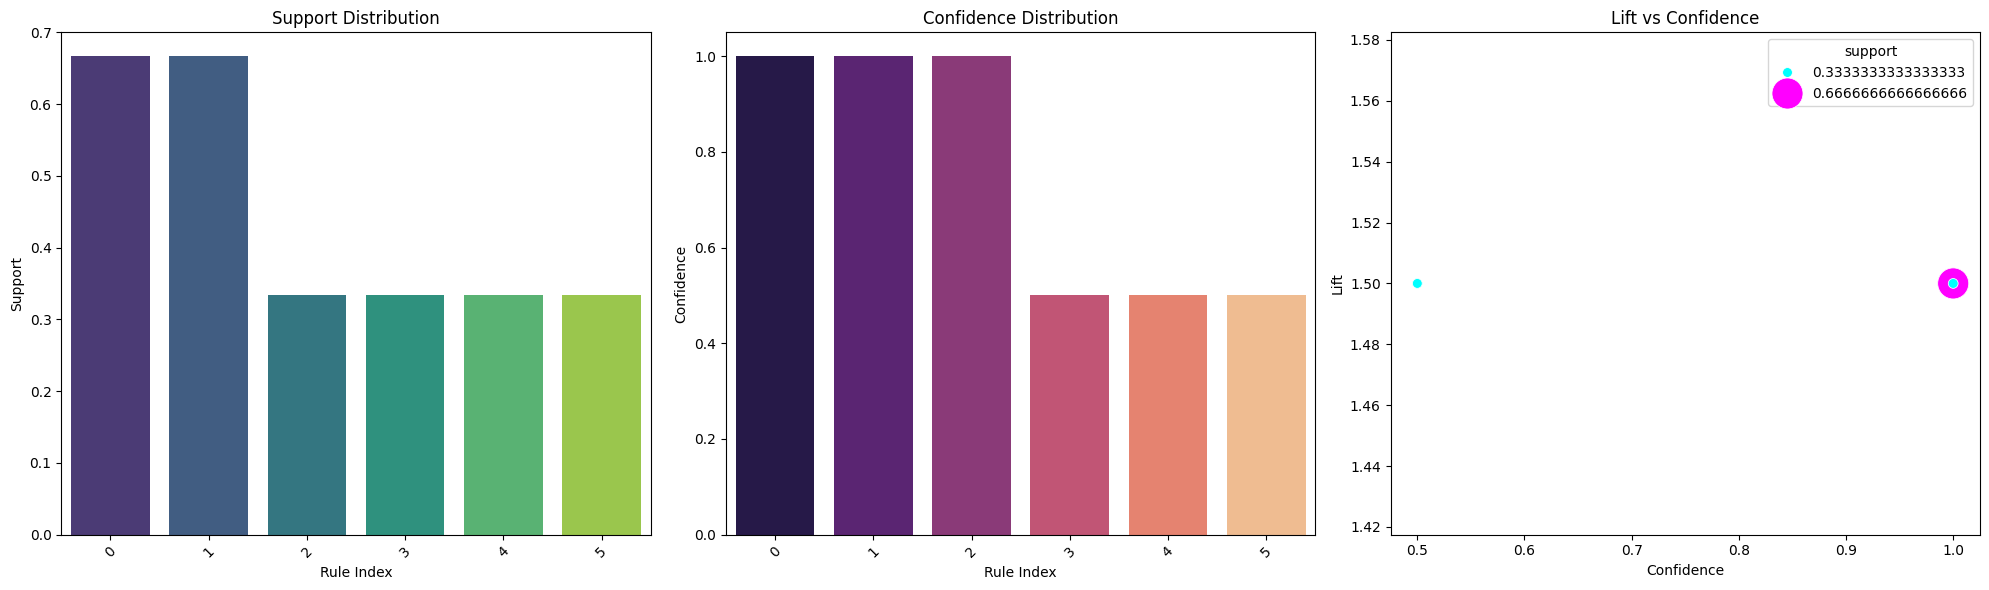

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.barplot(x=rules_df.index, y="support", data=rules_df, ax=axes[0], palette="viridis")
axes[0].set_title("Support Distribution")
axes[0].set_xlabel("Rule Index")
axes[0].set_ylabel("Support")
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(x=rules_df.index, y="confidence", data=rules_df, ax=axes[1], palette="magma")
axes[1].set_title("Confidence Distribution")
axes[1].set_xlabel("Rule Index")
axes[1].set_ylabel("Confidence")
axes[1].tick_params(axis='x', rotation=45)

sns.scatterplot(x="confidence", y="lift", size="support", hue="support", data=rules_df, ax=axes[2], sizes=(50, 500), palette="cool")
axes[2].set_title("Lift vs Confidence")
axes[2].set_xlabel("Confidence")
axes[2].set_ylabel("Lift")

plt.tight_layout()
plt.show()


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


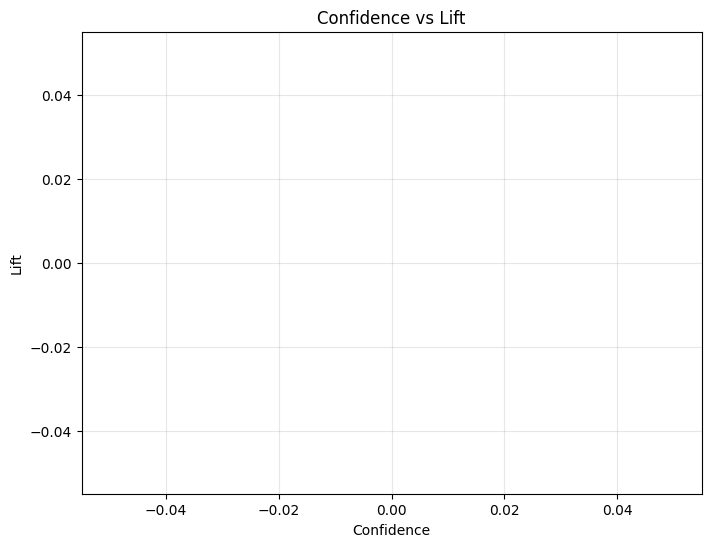

In [ ]:
# Scatter plot for confidence vs lift
plt.figure(figsize=(8, 6))
plt.scatter(rules['confidence'], rules['lift'], alpha=0.7, color='purple')
plt.title('Confidence vs Lift')
plt.xlabel('Confidence')
plt.ylabel('Lift')
plt.grid(alpha=0.3)
plt.show()


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


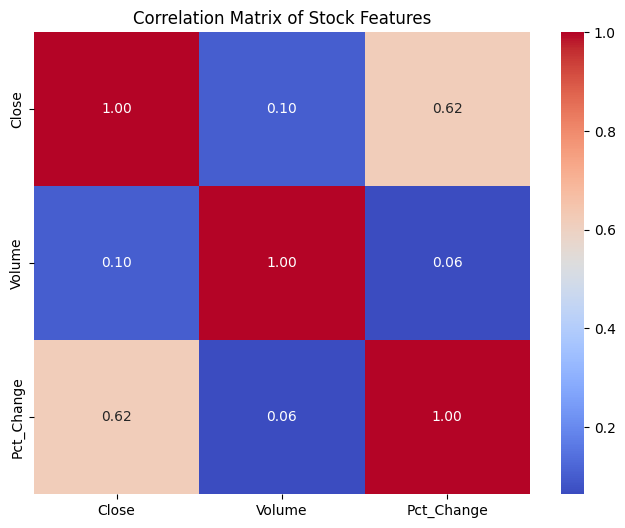

In [ ]:
import seaborn as sns
correlation_matrix = data[['Close', 'Volume', 'Pct_Change']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Stock Features')
plt.show()
